## Simple Linear Regression

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline

In [2]:
## Read the dataset
df=pd.read_csv('height-weight.csv')
df.head()

,Weight,Height
0,45,120
1,58,135
2,48,123
3,60,145
4,70,160


Text(0, 0.5, 'Height')

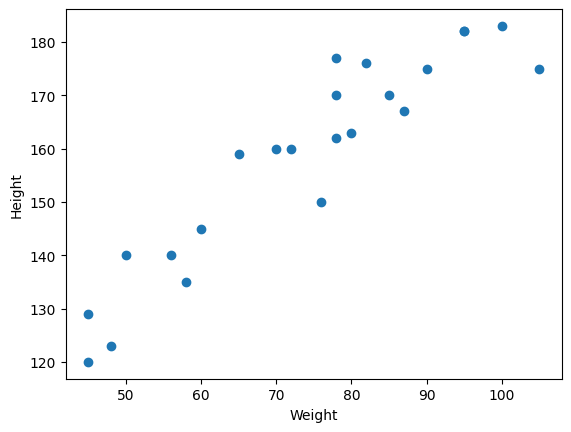

In [3]:
plt.scatter(df['Weight'],df['Height'])
plt.xlabel("Weight")
plt.ylabel("Height")

In [ ]:
## Divide our dataset into independent and dependent features.

X=df[['Weight']] ## independent feature
y=df['Height'] ## dependent feature

In [5]:
## Train test split
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.20,random_state=42)

In [6]:
X.shape

(23, 1)

In [7]:
X_train.shape,X_test.shape,y_train.shape,y_test.shape

((18, 1), (5, 1), (18,), (5,))

In [8]:
## standardize the dataset Train independent data
from sklearn.preprocessing import StandardScaler

In [ ]:
# Use standard scaler for feature scaling
scaler=StandardScaler()

In [10]:
X_train.head()

,Weight
12,105
1,58
13,100
5,78
2,48


In [ ]:
# Apply the scaling on train and test data, in test data we do not fit the scaler,
# again cause it may lead to data leakage.


X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

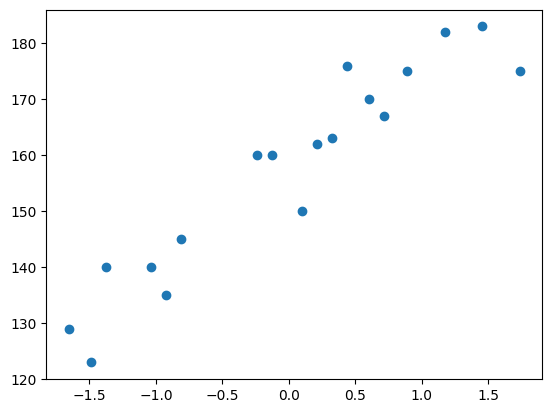

In [ ]:
# Visualizing the training data

plt.scatter(X_train, y_train)
plt.xlabel('Weight')
plt.ylabel('Height')
plt.title('Training Data')

In [ ]:
## Train the Simple Linear Regression Model from sklearn library


from sklearn.linear_model import LinearRegression

In [ ]:
regressor = LinearRegression() # create an object of LinearRegression class

In [ ]:
regressor.fit(X_train, y_train)

LinearRegression()

In [16]:
print("The slope or coefficient of weight is ",regressor.coef_)
print("Intercept:",regressor.intercept_)

The slope or coefficient of weight is  [17.03440872]
Intercept: 157.5


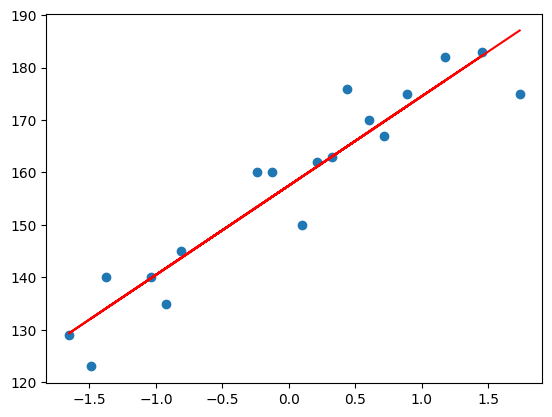

In [17]:
plt.scatter(X_train, y_train)
plt.plot(X_train, regressor.predict(X_train), 'r')

### prediction of train data
1. predicted height output= intercept +coef_(Weights)
2. y_pred_train =157.5 + 17.03(X_train)
          
### prediction of test data
1. predicted height output= intercept +coef_(Weights)
2. y_pred_test =157.5 + 17.03(X_test)

In [18]:
y_pred_test = regressor.predict(X_test)

In [19]:
y_pred_test, y_test

(array([161.08467086, 161.08467086, 129.3041561 , 177.45645118,
        148.56507414]),
 15    177
 9     170
 0     120
 8     182
 17    159
 Name: Height, dtype: int64)

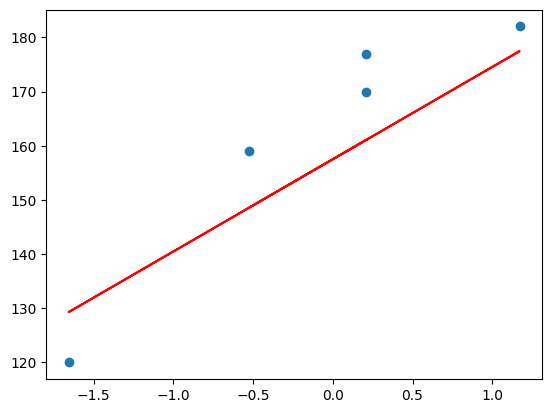

In [20]:
plt.scatter(X_test, y_test)
plt.plot(X_test, regressor.predict(X_test), 'r')

## Performance Metrics

## MSE,MAE,RMSE
## R square and adjusted R square

In [21]:
from sklearn.metrics import mean_squared_error,mean_absolute_error

In [ ]:
mse=mean_squared_error(y_test, y_pred_test)
mae=mean_absolute_error(y_test, y_pred_test)
rmse=np.sqrt(mse)
print(mse)
print(mae)
print(rmse)

109.77592599051664
9.822657814519232
10.477400726827081


## R square 
Formula

**R^2 = 1 - SSR/SST**


R^2	=	coefficient of determination
SSR	=	sum of squares of residuals
SST	=	total sum of squares

In [ ]:
from sklearn.metrics import r2_score
score=r2_score(y_test, y_pred_test)

In [24]:
score

0.776986986042344

## Adjusted R Square

**Adjusted R2 = 1 – [(1-R2)*(n-1)/(n-k-1)]**

where:

R2: The R2 of the model
n: The number of observations
k: The number of predictor variables

In [25]:
#display adjusted R-squared
1 - (1-score)*(len(y_test)-1)/(len(y_test)-X_test.shape[1]-1)

0.7026493147231252

In [26]:
regressor

LinearRegression()

In [27]:
## new data point weight is 80

scaled_weight=scaler.transform([[80]])
scaled_weight

/home/here_im/ml_venv/lib/python3.10/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([[0.32350772]])

In [28]:
scaled_weight[0]

array([0.32350772])

In [29]:
print("The height prediction for weight 80 kg is :",regressor.predict([scaled_weight[0]]))

The height prediction for weight 80 kg is : [163.01076266]


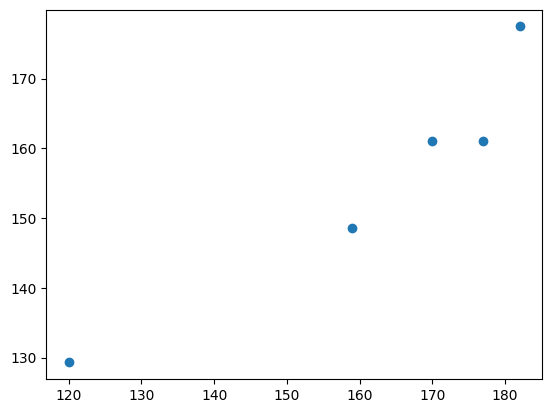

In [30]:
## Assumptions
## plot a scatter plot for the prediction
plt.scatter(y_test,y_pred_test)

In [31]:
## Residuals
residuals = y_test - y_pred_test
residuals

15    15.915329
9      8.915329
0     -9.304156
8      4.543549
17    10.434926
Name: Height, dtype: float64

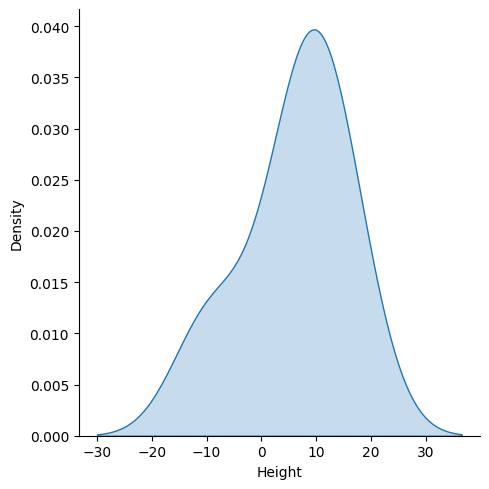

In [32]:
## plot this residuals
import seaborn as sns
sns.displot(residuals, kind="kde", fill=True)

<Axes: xlabel='Height', ylabel='Density'>

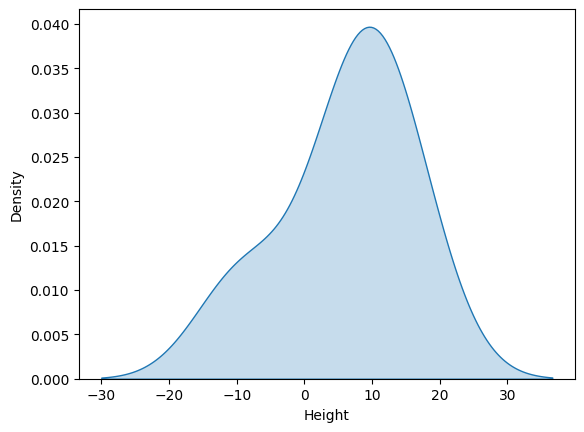

In [33]:
import seaborn as sns
sns.kdeplot(residuals, fill=True)

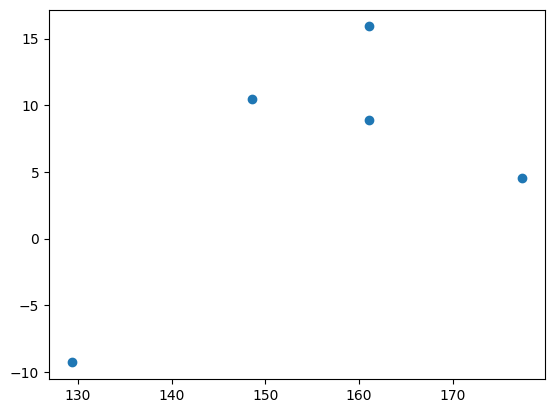

In [34]:
## Scatter plot with respect to prediction and residuals
## uniform distribution
plt.scatter(y_pred_test, residuals)

In [35]:
import statsmodels.api as sm

In [ ]:
model = sm.OLS(X_train, y_train).fit()
predictions = model.predict(X_test)

In [37]:
print(model.summary())

                                 OLS Regression Results                                
Dep. Variable:                 Height   R-squared (uncentered):                   0.012
Model:                            OLS   Adj. R-squared (uncentered):             -0.047
Method:                 Least Squares   F-statistic:                             0.1986
Date:                Fri, 17 Oct 2025   Prob (F-statistic):                       0.661
Time:                        21:47:11   Log-Likelihood:                         -116.62
No. Observations:                  18   AIC:                                      235.2
Df Residuals:                      17   BIC:                                      236.1
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

/home/here_im/ml_venv/lib/python3.10/site-packages/scipy/stats/_axis_nan_policy.py:531: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=18
  res = hypotest_fun_out(*samples, **kwds)


In [38]:
regressor.coef_

array([17.03440872])

In [39]:
regressor.intercept_

157.5